In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("BostonHousing.csv")  # change path if needed

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [6]:
df['rm'].fillna(df['rm'].mean(), inplace=True)

C:\Users\Payal\AppData\Local\Temp\ipykernel_29964\3418382971.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['rm'].fillna(df['rm'].mean(), inplace=True)


0      6.575
1      6.421
2      7.185
3      6.998
4      7.147
       ...  
501    6.593
502    6.120
503    6.976
504    6.794
505    6.030
Name: rm, Length: 506, dtype: float64

In [7]:
X = df.drop('medv', axis=1)   # features
y = df['medv']                # target (house price)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([28.98141872, 36.01423173, 14.82430919, 25.0229357 , 18.77077366,
       23.25088901, 17.65921355, 14.3312157 , 23.01799598, 20.61923725,
       24.91477542, 18.65745019, -6.08024872, 21.75669434, 19.23608436,
       26.18483638, 20.65521785,  5.80089206, 40.48814091, 17.61519761,
       27.23332555, 30.05317191, 11.3328674 , 24.1383693 , 17.86296594,
       15.84437533, 22.77843276, 14.57521147, 22.4366747 , 19.18599316,
       22.42492941, 25.20638527, 25.92633141, 17.7144719 , 16.77105313,
       16.96804968, 31.22105015, 20.12198187, 23.76217047, 24.62043216,
       13.93268126, 32.23349827, 42.65936186, 17.32784863, 27.25487922,
       16.99795581, 14.06061007, 25.89028965, 20.29789589, 29.94485087,
       21.30603148, 34.33630976, 16.03389489, 26.20109252, 39.52390271,
       22.58297123, 18.84703823, 32.71222177, 25.05158461, 12.90043059,
       20.56663412, 30.48440628, 31.50592444, 15.8863132 , 20.23931509,
       16.71637229, 20.52048882, 25.95211452, 30.60472918, 11.60

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 24.404825188146408
R2 Score: 0.6672089705941889


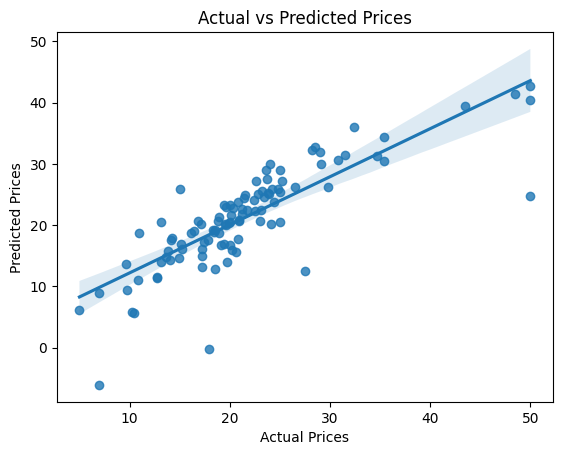

In [ ]:
sns.regplot(x = y_test, y = y_pred, ci= 95);
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()